In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
from RNN import *

## Data Import and Preprocessing

Import raw data:

In [2]:
cpi_urban = pd.read_excel('data/cpi_urban.xlsx')
imf_data = pd.read_csv('data/imf_time_series_govt_exp.csv')
repo_data = pd.read_csv('data/repo.csv')
usdzar_data = pd.read_csv('data/usdzar.csv')
za_real_gdp_data = pd.read_csv('data/za_real_gdp.csv')
zaronia_data = pd.read_csv('data/zaronia.csv')

/var/folders/pr/05vbp6_94f3300tknkj0jbw40000gn/T/ipykernel_67374/3812176795.py:2: DtypeWarning: Columns (13,15,21,24) have mixed types. Specify dtype option on import or set low_memory=False.
  imf_data = pd.read_csv('data/imf_time_series_govt_exp.csv')


Isolate the actual time series data required

In [3]:
# CPI Average Prices All Urban (White Bread)
white_bread_cpi_df = cpi_urban[(cpi_urban['H03']==1113101) & (cpi_urban['H07']==10902)].drop(columns=cpi_urban.columns[0:10]).T.rename(columns={15:'Value'})
white_bread_cpi_df.index = pd.to_datetime(white_bread_cpi_df.index.str[1:], format="%Y%m", errors="coerce")
white_bread_cpi_df = white_bread_cpi_df[white_bread_cpi_df.index.notna()]
white_bread_cpi_df = white_bread_cpi_df.rename_axis("Date").reset_index()

# ZARONIA-REPO spread
zaronia_data['Date'] = pd.to_datetime(zaronia_data['Date'])
repo_data['Date'] = pd.to_datetime(repo_data['Date'])
zaronia_data = zaronia_data.set_index('Date')['Rate']
repo_data = repo_data.set_index('Date')['Value']
zaronia_repo_spread_df = (repo_data - zaronia_data).dropna()
zaronia_repo_spread_df = zaronia_repo_spread_df.rename("Value").rename_axis("Date").reset_index()

# South African Real GDP data
za_real_gdp_data.columns = ['Date', 'Value']
za_real_gdp_df = za_real_gdp_data.set_index('Date')['Value'].rename_axis("Date").reset_index()
za_real_gdp_df['Value'] = za_real_gdp_df['Value'] / 1e6

# SA annual government expenditure
sa_govt_exp_df = imf_data[imf_data['SERIES_CODE']=='ZAF.GGX.A'].drop(columns=imf_data.columns[:27]).T.dropna()
sa_govt_exp_df.columns = ['Value']
sa_govt_exp_df.index.rename('Date', inplace=True)
sa_govt_exp_df = sa_govt_exp_df.rename_axis("Date").reset_index()

# USD/ZAR exchange rate data
usdzar_df = usdzar_data.set_index('Date')['Value'].rename_axis("Date").reset_index()

Difference the datasets that require differencing:

In [16]:
datasets = {
    "bread":   diff(white_bread_cpi_df,   'diff'),
    "spread":     diff(zaronia_repo_spread_df,     'none'),
    "gdp":  diff(za_real_gdp_df,  "diff"),
    "govt_exp": diff(sa_govt_exp_df, "diff"),
    "usdzar":  diff(usdzar_df,  "diff"),
}

<Axes: >

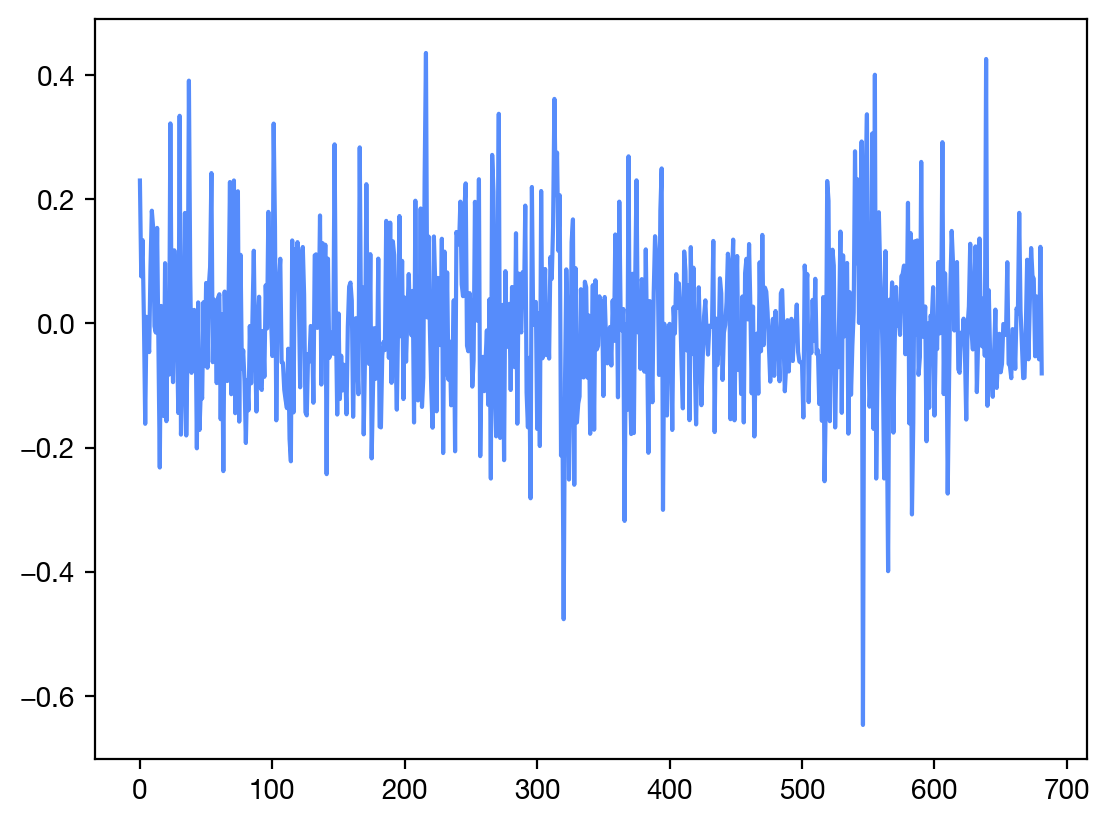

In [18]:
# just seeing what the datasets look like after differencing
datasets['usdzar']['Value'].plot()

## Plotting of datasets (before differencing)

In [66]:
# attemping to make nice plots for the report
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "custom",
    "pdf.fonttype": 42,
    "savefig.dpi": 600,
    "figure.dpi": 200,
})

def plot_series(df, title=None, ylabel=None, color="black", savepath=None):
    data = df.iloc[:, :2].copy()
    data.columns = ["date", "value"]
    data["date"] = pd.to_datetime(data["date"])
    data = data.sort_values("date")

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(data["date"], data["value"], color=color, linewidth=1.2)

    locator = mdates.AutoDateLocator(maxticks=6)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    if title:
        ax.set_title(title, loc="left")
    if ylabel:
        ax.set_ylabel(ylabel)

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, bbox_inches="tight")
    return fig, ax

(<Figure size 1400x600 with 1 Axes>, <Axes: ylabel='ZAR per USD'>)

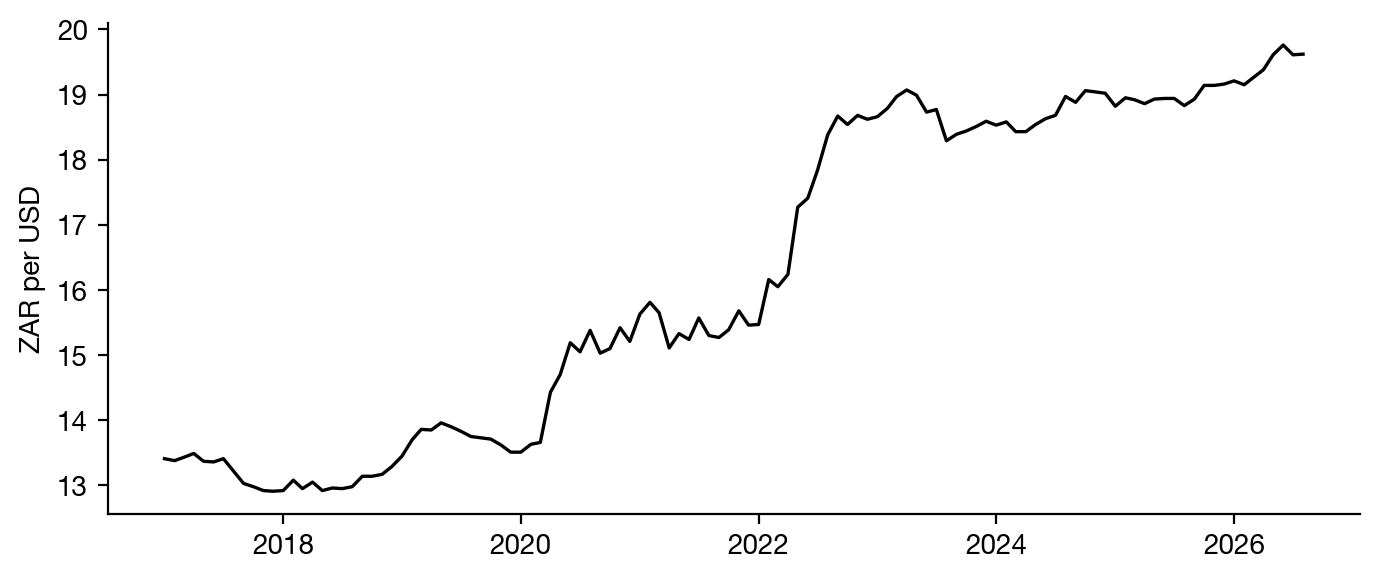

In [71]:
plot_series(white_bread_cpi_df, ylabel="ZAR per USD")

## Hyperparam tuning

In [26]:
# define the hyperparam tuning vars
grid = {
    'window_size': [3,9,12], # input dim size
    'hidden_size': [4,8,16],
    'learning_rate': [1e-3, 1e-2],
    'weight_decay': [0, 1e-4, 1e-3]
}
# grid specific to the govt expenditure dataset because that dataset is so short
govt_grid = {
    'window_size': [1,2,3],
    'hidden_size': [2,4],
    'learning_rate': [1e-3, 1e-2],
    'weight_decay': [0, 1e-4, 1e-3]
}
models = {"Elman": ElmanRNN, "Jordan": JordanRNN, "Multi": MultiRNN}
N_SPLITS=5

In [27]:
# tune every model-dataset pair on val folds
best_params, tuning_tables = {}, {}

for df_name, series in datasets.items():
    for m_name, Model in models.items():
        print(f"Tuning {m_name} on {df_name}...")
        table = tune(series, Model, grid, n_splits=N_SPLITS) if df_name!='govt_exp' else tune(series, Model, govt_grid, n_splits=N_SPLITS)
        tuning_tables[(df_name, m_name)] = table
        best = table.iloc[0]
        best_params[(df_name, m_name)] = {
            "p": int(best["p"]), "n_hidden": int(best["n_hidden"]),
            "lr": float(best["lr"]), "wd": float(best["wd"]),
        }

best_params_df = pd.DataFrame(best_params).T.rename_axis(["dataset", "model"])
best_params_df.to_csv("best_params.csv")
print(best_params_df)

Tuning Elman on bread...
Tuning Jordan on bread...
Tuning Multi on bread...
Tuning Elman on spread...
Tuning Jordan on spread...
Tuning Multi on spread...
Tuning Elman on gdp...
Tuning Jordan on gdp...
Tuning Multi on gdp...
Tuning Elman on govt_exp...
Tuning Jordan on govt_exp...
Tuning Multi on govt_exp...
Tuning Elman on usdzar...
Tuning Jordan on usdzar...
Tuning Multi on usdzar...
                    p  n_hidden     lr      wd
dataset  model                                
bread    Elman    9.0      16.0  0.010  0.0001
         Jordan   3.0       4.0  0.001  0.0000
         Multi    9.0      16.0  0.001  0.0000
spread   Elman    9.0       8.0  0.010  0.0001
         Jordan   3.0       8.0  0.010  0.0010
         Multi    9.0      16.0  0.010  0.0000
gdp      Elman   12.0       4.0  0.010  0.0000
         Jordan  12.0       8.0  0.010  0.0000
         Multi    3.0       4.0  0.010  0.0000
govt_exp Elman    1.0       2.0  0.010  0.0000
         Jordan   1.0       2.0  0.010  0.0000


## Model Building

In [40]:
# now evaluate the performance of each model-dataset pair with the model's best config, on the test fold
rows, forecasts = [], {}

for d_name, series in datasets.items():
    for m_name, Model in models.items():
        fc = np.full(len(series), np.nan)
        for fold, (tr, te) in enumerate(TimeSeriesSplit(n_splits=N_SPLITS).split(series)):
            r = run_fold(series, tr, te, Model, **best_params[(d_name, m_name)])
            rows.append({"dataset": d_name, "model": m_name, "fold": fold,
                         "rmse": r["rmse"], "naive_rmse": r["naive_rmse"]})
            fc[r["idx"]] = r["pred"]
        forecasts[(d_name, m_name)] = fc

results = pd.DataFrame(rows)
results.to_csv("results.csv", index=False)

In [45]:
results.groupby(["dataset", "model"])[["rmse","naive_rmse"]].mean().reset_index()

,dataset,model,rmse,naive_rmse
0,bread,Elman,0.221121,0.296093
1,bread,Jordan,0.226532,0.296093
2,bread,Multi,0.218786,0.296093
3,gdp,Elman,0.015530,0.024263
4,gdp,Jordan,0.015832,0.024263
5,gdp,Multi,0.016290,0.024263
6,govt_exp,Elman,37.818936,36.682078
7,govt_exp,Jordan,40.518848,36.682078
8,govt_exp,Multi,39.243354,36.682078
9,spread,Elman,0.007518,0.008292


/var/folders/pr/05vbp6_94f3300tknkj0jbw40000gn/T/ipykernel_67374/904461864.py:14: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  fig.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  fig.canvas.print_figure(bytes_io, **kw)


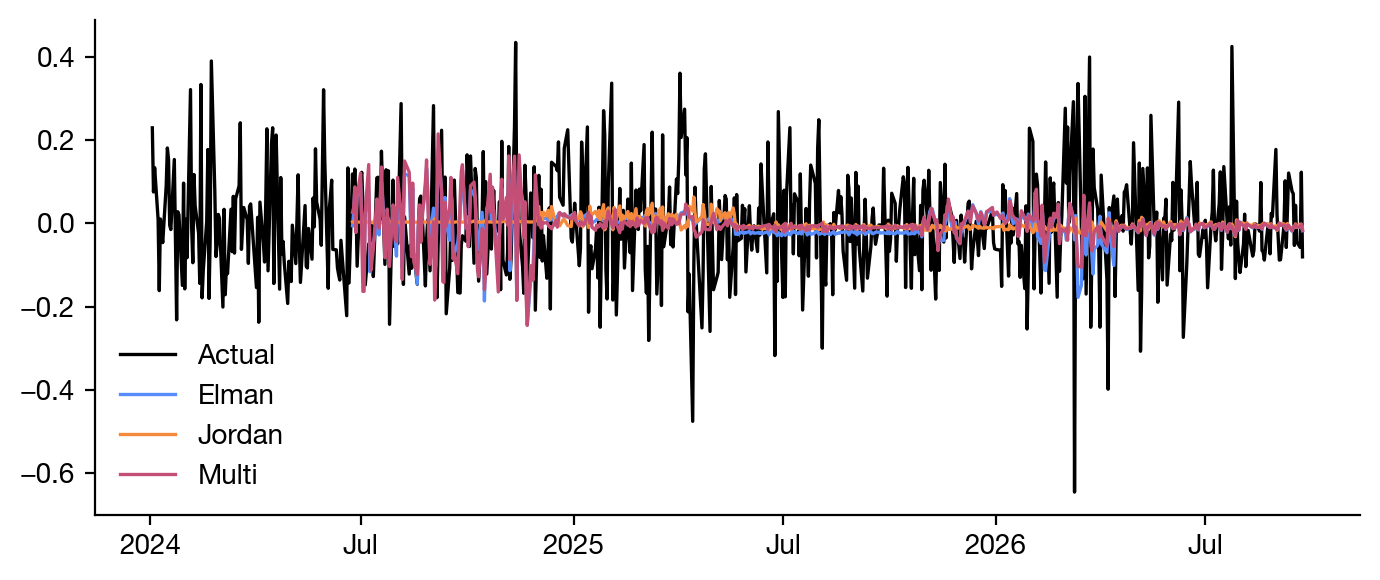

In [65]:
def plot_step_ahead_forecasts(d_name):
    df = datasets[d_name]
    dates = pd.to_datetime(df["Date"])
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(dates, df["Value"], color="black", linewidth=1.2, label="Actual")
    for m_name in models:
        ax.plot(dates, forecasts[(d_name, m_name)], linewidth=1.2, label=m_name)
    locator = mdates.AutoDateLocator(maxticks=6)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

plot_step_ahead_forecasts('usdzar')